# Machine Learning Lab (23CSE301) – Exercise Solutions
**Chapter 10**


In [1]:
# ---- Common imports and dataset loader ----
import os, re, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

# ---- Dataset loader ----
DATA_DIR = "data"
def load_data(filename, url, **read_csv_kwargs):
    """Read a real dataset. Uses ./data/<filename> if present (e.g. downloaded from Kaggle);
    otherwise downloads the public copy given in `url` and caches it in ./data/."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        os.makedirs(DATA_DIR, exist_ok=True)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp, open(path, "wb") as f:
            f.write(resp.read())
    return pd.read_csv(path, **read_csv_kwargs)

print("Libraries loaded")

Libraries loaded


# 10.6 K-Means Clustering – Exercises
## Exercise 1 – Old Faithful geyser eruption segmentation
Cluster eruptions by **waiting time** between eruptions and **duration** of the eruption.

> **Dataset – Old Faithful geyser eruptions (the classic R `faithful` data; no Kaggle listing found).**
> Source used: <https://raw.githubusercontent.com/gchoi/Dataset/master/OldFaithful.csv>
> **Records:** 272 eruptions · **Features:** `duration` (= `TimeEruption`, min) and `waiting` (= `TimeWaiting`, min) · **Target:** none (unsupervised).
> **Preprocessing:** columns renamed; both features standardised before K-Means because their ranges differ a lot.
> **Why it fits:** it is the textbook two-cluster example (short eruption / short wait vs. long eruption / long wait).

In [39]:
geyser_raw = load_data("OldFaithful.csv",
                       "https://raw.githubusercontent.com/gchoi/Dataset/master/OldFaithful.csv")
geyser = geyser_raw.rename(columns={"TimeEruption": "duration", "TimeWaiting": "waiting"})[["duration", "waiting"]]

print(geyser.shape, "| nulls:", geyser.isnull().sum().sum())
geyser.describe().round(2)

(272, 2) | nulls: 0


,duration,waiting
count,272.00,272.00
mean,3.49,70.90
std,1.14,13.59
min,1.60,43.00
25%,2.16,58.00
50%,4.00,76.00
75%,4.45,82.00
max,5.10,96.00


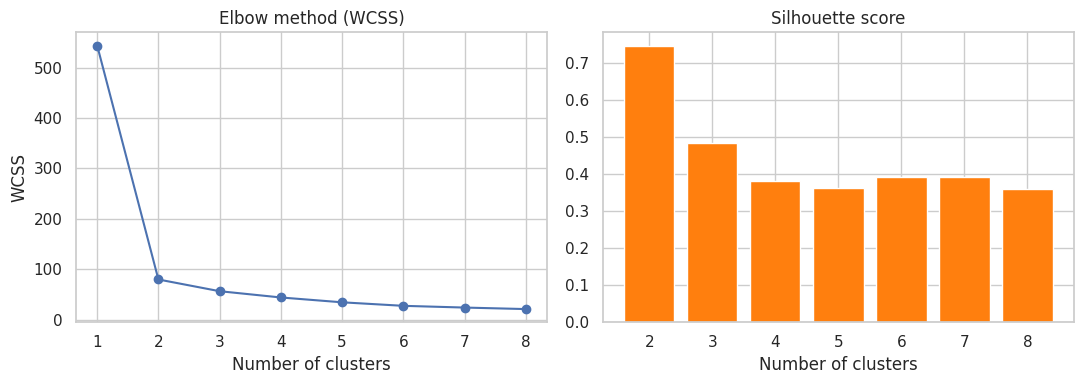

{2: np.float64(0.745), 3: np.float64(0.485), 4: np.float64(0.382), 5: np.float64(0.363), 6: np.float64(0.392), 7: np.float64(0.392), 8: np.float64(0.358)}


In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sc = StandardScaler()
Xg = sc.fit_transform(geyser[["waiting", "duration"]])       # scale: the two features have very different ranges

wcss, sil = [], {}
for k in range(1, 9):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42).fit(Xg)
    wcss.append(km.inertia_)
    if k > 1: sil[k] = silhouette_score(Xg, km.labels_)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(1, 9), wcss, "o-"); ax[0].set(title="Elbow method (WCSS)", xlabel="Number of clusters", ylabel="WCSS")
ax[1].bar(list(sil.keys()), list(sil.values()), color="tab:orange"); ax[1].set(title="Silhouette score", xlabel="Number of clusters")
plt.tight_layout(); plt.show()
print({k: round(v, 3) for k, v in sil.items()})

Cluster centres (original units):
         waiting  duration
cluster                   
0          80.08      4.30
1          54.59      2.05 

Cluster sizes:
cluster
0    174
1     98 

Silhouette score: 0.745


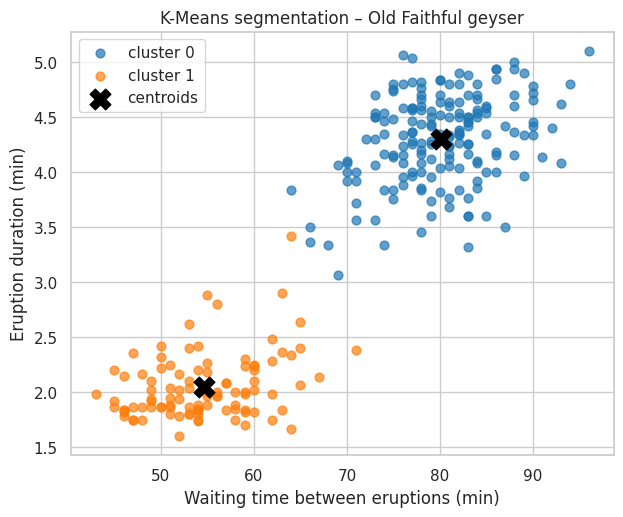

In [41]:
model = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=42)
geyser["cluster"] = model.fit_predict(Xg)
centers = pd.DataFrame(sc.inverse_transform(model.cluster_centers_), columns=["waiting", "duration"]).round(2)
centers.index.name = "cluster"

print("Cluster centres (original units):"); print(centers.to_string(), "\n")
print("Cluster sizes:"); print(geyser["cluster"].value_counts().sort_index().to_string(), "\n")
print(f"Silhouette score: {silhouette_score(Xg, geyser['cluster']):.3f}")

plt.figure(figsize=(7, 5.5))
for c, col in zip([0, 1], ["tab:blue", "tab:orange"]):
    s = geyser[geyser.cluster == c]; plt.scatter(s.waiting, s.duration, c=col, s=40, alpha=0.7, label=f"cluster {c}")
plt.scatter(centers.waiting, centers.duration, c="black", s=220, marker="X", label="centroids")
plt.xlabel("Waiting time between eruptions (min)"); plt.ylabel("Eruption duration (min)")
plt.title("K-Means segmentation – Old Faithful geyser"); plt.legend(); plt.show()

## Exercise 2 – Image compression with K-Means (396 × 396 × 3)
Every pixel is an RGB point; K-Means reduces the image to **K representative colours** (each pixel is replaced by its cluster centre).
A 396 × 396 × 3 crop of scikit-learn's bundled sample photo is used (swap in your own image with `PIL.Image.open(...).resize((396, 396))`).

Image shape: (396, 396, 3) | dtype: uint8


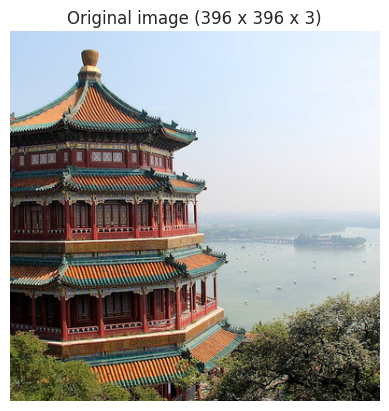

In [42]:
from sklearn.datasets import load_sample_image
china = load_sample_image("china.jpg")
img = china[10:406, 120:516]                       # crop to exactly 396 x 396 x 3
print("Image shape:", img.shape, "| dtype:", img.dtype)

plt.imshow(img); plt.axis("off"); plt.title("Original image (396 x 396 x 3)"); plt.show()

In [43]:
from sklearn.cluster import KMeans
import math

pixels = img.reshape(-1, 3) / 255.0                # 156,816 pixels x 3 channels
h, w, _ = img.shape
results, compressed = [], {}

for k in [2, 4, 8, 16, 32]:
    km = KMeans(n_clusters=k, n_init=1, random_state=42).fit(pixels)
    recon = km.cluster_centers_[km.labels_].reshape(h, w, 3)
    compressed[k] = recon
    mse = np.mean((img / 255.0 - recon) ** 2)
    orig_bits = h * w * 24
    comp_bits = h * w * math.ceil(math.log2(k)) + k * 24        # index per pixel + colour palette
    results.append({"K colours": k, "bits/pixel": math.ceil(math.log2(k)),
                    "PSNR (dB)": 10 * np.log10(1 / mse), "Compression ratio": orig_bits / comp_bits})

pd.DataFrame(results).round(2)

,K colours,bits/pixel,PSNR (dB),Compression ratio
0,2,1,17.10,23.99
1,4,2,21.47,12.00
2,8,3,24.49,8.00
3,16,4,27.21,6.00
4,32,5,29.79,4.80


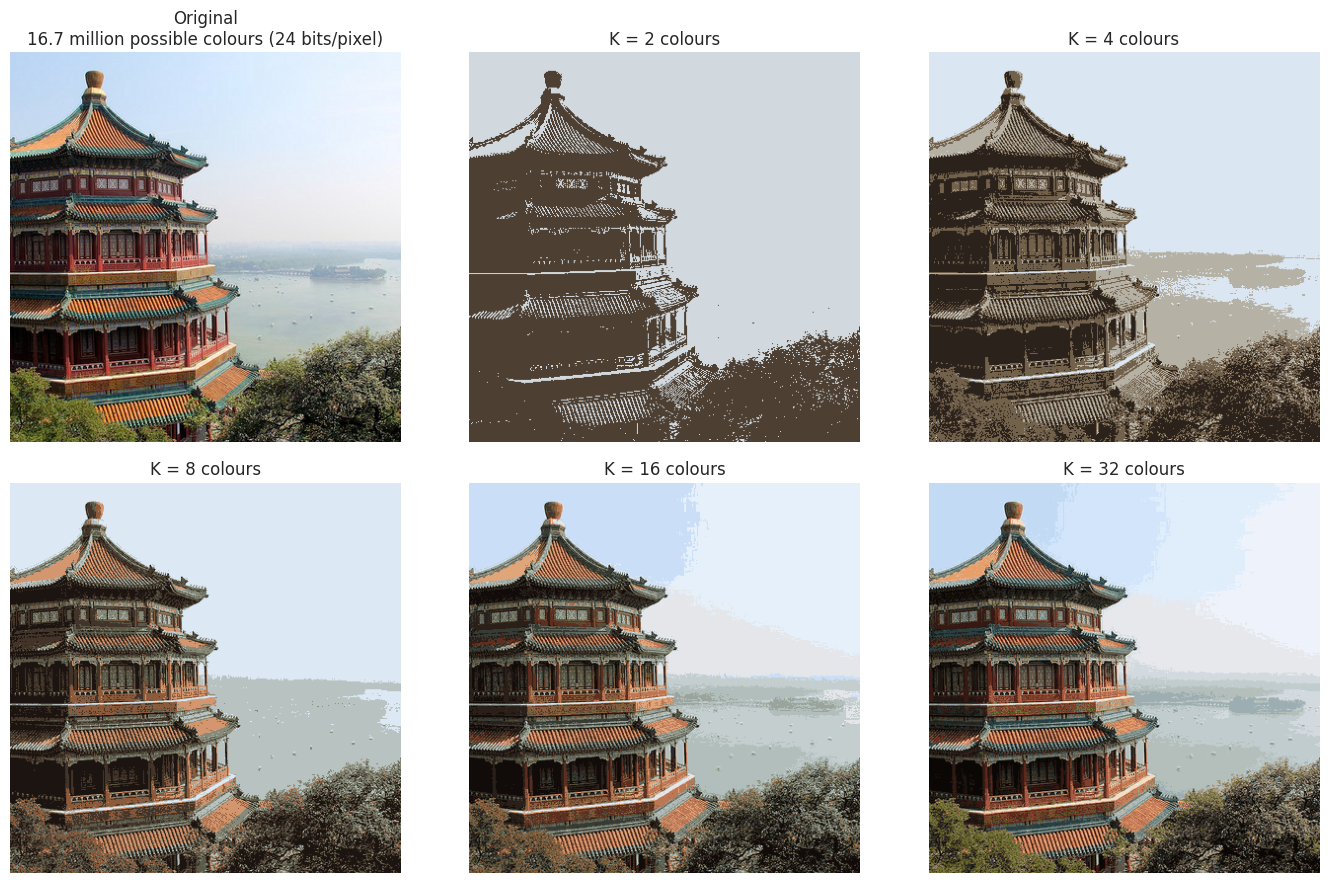

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes[0, 0].imshow(img); axes[0, 0].set_title("Original\n16.7 million possible colours (24 bits/pixel)")
for ax, (k, im) in zip(axes.ravel()[1:], compressed.items()):
    ax.imshow(im); ax.set_title(f"K = {k} colours")
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()